Aplicando II - Projeto Aplicado  - Análise Exploratória Dataset Varejo

Integrantes: Maiki Soares e Vanessa Cordeiro





In [ ]:
# 1. Carregar bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 2. Carregar o dataset direto do GitHub
url = "https://github.com/maikisoares00/Projeto_Aplicado_III_RetailWise/blob/main/dataset/dataset_varejo.xlsx"
url_raw = url.replace("github.com", "raw.githubusercontent.com").replace("/blob/", "/")

df = pd.read_excel(url_raw, engine="openpyxl")

# Exibir as 5 primeiras linhas
print("Prévia dos dados:")
display(df.head())

Prévia dos dados:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
# 3. Resumo estatístico (Quantity e UnitPrice)
# --- Ajuste de tipos: Quantity (int) e UnitPrice (float)

# Substitui vírgula por ponto, caso exista, e converte para float
df["UnitPrice"] = (
    df["UnitPrice"]
    .astype(str)                # garante string
    .str.replace(",", ".", regex=False)  # troca vírgula por ponto
    .astype(float)              # converte pra float
)

# Converte quantidade para inteiro (ou int64)
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce").fillna(0).astype(int)

# Agora podemos gerar o resumo estatístico corretamente
print("\nResumo estatístico (após tratar tipos):")
display(df[["Quantity", "UnitPrice"]].describe())



Resumo estatístico (após tratar tipos):


,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


from matplotlib import pyplot as plt
_df_0['Quantity'].plot(kind='hist', bins=20, title='Quantity')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['UnitPrice'].plot(kind='hist', bins=20, title='UnitPrice')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2.plot(kind='scatter', x='Quantity', y='UnitPrice', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['Quantity'].plot(kind='line', figsize=(8, 4), title='Quantity')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_4['UnitPrice'].plot(kind='line', figsize=(8, 4), title='UnitPrice')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
# 4. Verificar dados ausentes
print("\nValores ausentes por coluna:")
display(df.isnull().sum())



Valores ausentes por coluna:


,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


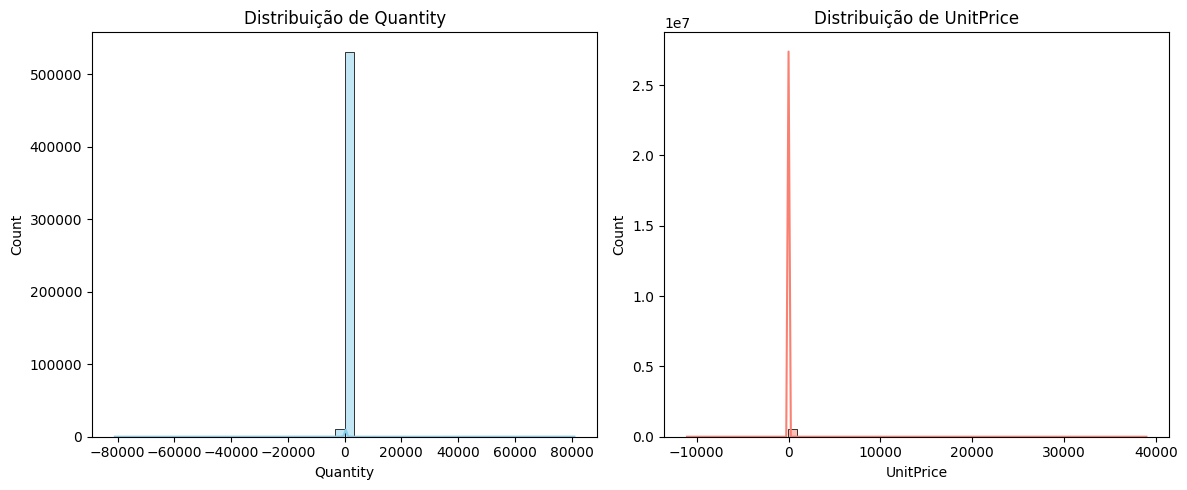

In [ ]:
# 5. Análise de distribuição
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
sns.histplot(df["Quantity"], bins=50, kde=True, color="skyblue")
plt.title("Distribuição de Quantity")

plt.subplot(1, 2, 2)
sns.histplot(df["UnitPrice"], bins=50, kde=True, color="salmon")
plt.title("Distribuição de UnitPrice")

plt.tight_layout()
plt.show()

In [ ]:
# 6. Frequência de compras por cliente
print("\nFrequência de compras por CustomerID:")
display(df["CustomerID"].value_counts().head(10))


Frequência de compras por CustomerID:


,count
CustomerID,
17841.0,7983
14911.0,5903
14096.0,5128
12748.0,4642
14606.0,2782
15311.0,2491
14646.0,2085
13089.0,1857
13263.0,1677


In [ ]:
# 7. Produtos mais populares (maior soma de Quantity)
print("\nTop 10 produtos mais vendidos:")
top_produtos = df.groupby("StockCode")["Quantity"].sum().sort_values(ascending=False).head(10)
display(top_produtos)



Top 10 produtos mais vendidos:


,Quantity
StockCode,
22197,56450
84077,53847
85099B,47363
85123A,38830
84879,36221
21212,36039
23084,30646
22492,26437
22616,26315



Distribuição de transações por Country:


,count
Country,
United Kingdom,495478
Germany,9495
France,8557
EIRE,8196
Spain,2533
Netherlands,2371
Belgium,2069
Switzerland,2002
Portugal,1519


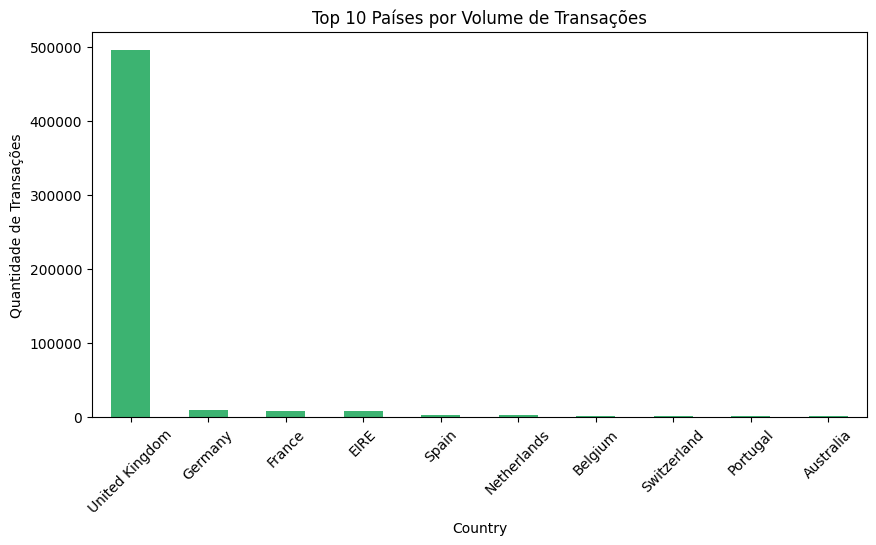

In [ ]:
# 8. Análise geográfica - transações por país
print("\nDistribuição de transações por Country:")
display(df["Country"].value_counts().head(10))

# Visualização da distribuição geográfica
plt.figure(figsize=(10,5))
df["Country"].value_counts().head(10).plot(kind='bar', color='mediumseagreen')
plt.title("Top 10 Países por Volume de Transações")
plt.xlabel("Country")
plt.ylabel("Quantidade de Transações")
plt.xticks(rotation=45)
plt.show()